In [ ]:
# Importing all the necessary libraries
from transformers import T5Tokenizer
from IPython.display import Javascript
from datasets import load_dataset, Dataset, DatasetDict
import pandas as pd
from transformers import T5ForConditionalGeneration, T5Tokenizer, TrainingArguments, Trainer, DataCollatorForSeq2Seq
import torch
import gc
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

In [ ]:
# Confirming GPU availability
print(f"GPU available: {torch.cuda.is_available()}")
print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory/1e9:} GB")

GPU available: True
GPU memory: 15.828320256 GB


In [ ]:
# Anti-disconnect mechanism
Javascript("""
function ClickConnect(){
  console.log("Working");
  document.querySelector("colab-toolbar-button#connect").click()
}
setInterval(ClickConnect, 60 * 1000)
""")

<IPython.core.display.Javascript object>

In [ ]:
# Load the CSVs as pandas DataFrames first
base_path = "/content/drive/MyDrive/test-train-val-new-fact-cheker-ml-datasets/"
train_df = pd.read_csv("/content/drive/MyDrive/test-train-val-new-fact-cheker-ml-datasets/train/train_data.csv")
val_df = pd.read_csv("/content/drive/MyDrive/test-train-val-new-fact-cheker-ml-datasets/validation/validation_data.csv")
test_df = pd.read_csv("/content/drive/MyDrive/test-train-val-new-fact-cheker-ml-datasets/test/test_data.csv")

# Convert 'target_text' to string to ensure compatibility with tokenization
for df in [train_df, val_df, test_df]:
    df['target_text'] = df['target_text'].astype(str)


# Convert to DatasetDict
dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "validation": Dataset.from_pandas(val_df),
    "test": Dataset.from_pandas(test_df)
})

In [ ]:
# Initialize tokenizer
tokenizer = T5Tokenizer.from_pretrained("google/flan-t5-base")

# Tokenization function
def preprocess(example):
    input_enc = tokenizer(
        example["input_text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )
    target_enc = tokenizer(
        example["target_text"],
        padding="max_length",
        truncation=True,
        max_length=16
    )
    input_enc["labels"] = target_enc["input_ids"]
    return input_enc

# Apply preprocessing
tokenized_data = dataset.map(preprocess, batched=True)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1875 [00:00<?, ? examples/s]

Map:   0%|          | 0/1875 [00:00<?, ? examples/s]

In [ ]:
# Importing the T5-Small model
model = T5ForConditionalGeneration.from_pretrained("google/flan-t5-base")

# Optimized TrainingArguments with frequent checkpointing
training_args = TrainingArguments(
    output_dir="./t5-factcheck",
    fp16=True,                           # Mixed precision for T4 GPU
    per_device_train_batch_size=8,      # Test if your GPU can handle this
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,       # Effective batch size = 24
    # optim="adamw_torch_fused",           # Optimized optimizer
    num_train_epochs=9,
    save_strategy="steps",               # Changed to steps-based saving
    save_steps=500,                      # Save every 500 steps
    save_total_limit=3,                  # Keep only 3 latest checkpoints
    eval_strategy="epoch",
    logging_dir="./logs",
    logging_steps=50,
    report_to="tensorboard",             # Enable TensorBoard
    push_to_hub=False,
    dataloader_pin_memory=True,         # Faster data loading
    dataloader_num_workers=2,           # Parallel data loading
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    label_smoothing_factor=0.1,
)

# Optimized data collator with dynamic padding
data_collator = DataCollatorForSeq2Seq(
    tokenizer,
    pad_to_multiple_of=8,               # Memory alignment
    return_tensors="pt"                 # PyTorch tensors by default
)


# Initializing the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_data["train"],
    eval_dataset=tokenized_data["validation"],
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [ ]:
# Clear memory before training
torch.cuda.empty_cache()
gc.collect()

# Start training
trainer.train()

Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Epoch,Training Loss,Validation Loss
1,0.040500,0.036070
2,0.037100,0.035199
3,0.035400,0.035014
4,0.036000,0.034936
5,0.034500,0.034703
6,0.035800,0.034646
7,0.035300,0.034500
8,0.033900,0.034672
9,0.034100,0.034571


TrainOutput(global_step=5625, training_loss=0.07104646499421861, metrics={'train_runtime': 1296.6412, 'train_samples_per_second': 104.115, 'train_steps_per_second': 4.338, 'total_flos': 4567785799680000.0, 'train_loss': 0.07104646499421861, 'epoch': 9.0})

In [ ]:
# Save final model
model.save_pretrained("t5-factcheck-model")
tokenizer.save_pretrained("t5-factcheck-model")

# Launch TensorBoard
%load_ext tensorboard
%tensorboard --logdir ./logs

print("Training complete and model saved!")

# **Evaluation & Testing**

In [ ]:
# Evaluating All Test Samples
def predict(statement):
    input_text = "classify: " + statement
    input_ids = tokenizer(input_text, return_tensors="pt", truncation=True, padding=True).input_ids.to(model.device)
    output = model.generate(input_ids)
    return tokenizer.decode(output[0], skip_special_tokens=True)

true_labels, predicted_labels = [], []

for example in tokenized_data["test"]:
    input_text = example["input_text"]
    true_label = example["target_text"]
    prediction = predict(input_text.replace("classify: ", ""))
    true_labels.append(true_label)
    predicted_labels.append(prediction)

print(classification_report(true_labels, predicted_labels))

              precision    recall  f1-score   support

       False       0.73      0.70      0.71       938
        True       0.71      0.74      0.73       937

    accuracy                           0.72      1875
   macro avg       0.72      0.72      0.72      1875
weighted avg       0.72      0.72      0.72      1875




Accuracy: 0.7195
F1 Score: 0.7260


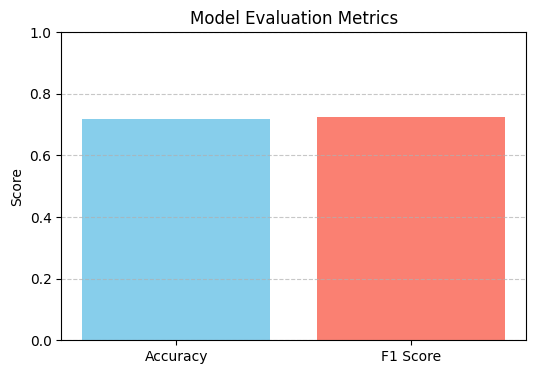

In [ ]:
# Convert labels to lowercase for consistent matching
true_labels_clean = [label.lower().strip() for label in true_labels]
predicted_labels_clean = [label.lower().strip() for label in predicted_labels]

# Calculate metrics
acc = accuracy_score(true_labels_clean, predicted_labels_clean)
f1 = f1_score(true_labels_clean, predicted_labels_clean, pos_label="true")  # or "false", based on what is positive class

print(f"\nAccuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")

# Plotting
plt.figure(figsize=(6,4))
plt.bar(["Accuracy", "F1 Score"], [acc, f1], color=["skyblue", "salmon"])
plt.title("Model Evaluation Metrics")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.show()

<Figure size 500x500 with 0 Axes>

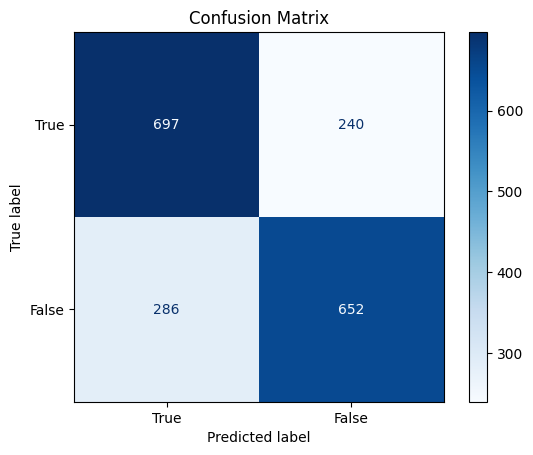

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(true_labels_clean, predicted_labels_clean, labels=["true", "false"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["True", "False"])

# Plot
plt.figure(figsize=(5, 5))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

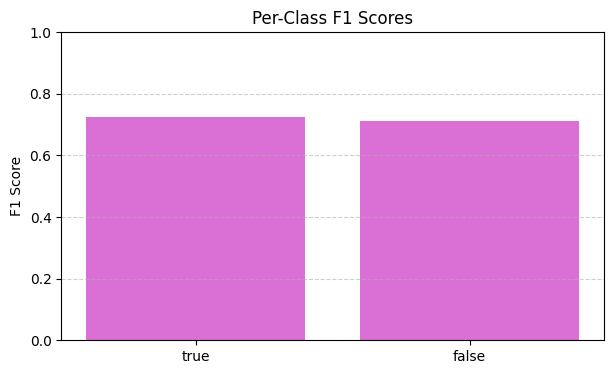

In [ ]:
# Get precision, recall, f1-score for each class
labels = ["true", "false"]
precision, recall, f1_scores, _ = precision_recall_fscore_support(
    true_labels_clean, predicted_labels_clean, labels=labels
)

# Plot per-class F1 scores
plt.figure(figsize=(7, 4))
x = range(len(labels))
plt.bar(x, f1_scores, tick_label=labels, color="orchid")
plt.title("Per-Class F1 Scores")
plt.ylim(0, 1)
plt.ylabel("F1 Score")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()